In [6]:
import os
import cv2
import math
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import Counter,defaultdict

plt.rcParams["figure.figsize"]=(10,6)

In [7]:
DATASET_PATH = "../../dataset"

TRAIN_IMAGES = os.path.join(DATASET_PATH,"train","images")
TRAIN_LABELS = os.path.join(DATASET_PATH,"train","labels")

VALID_IMAGES = os.path.join(DATASET_PATH,"valid","images")
VALID_LABELS = os.path.join(DATASET_PATH,"valid","labels")

CLASS_NAMES=[
    "Calcium Deficiency",
    "Healthy",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Phosphorus Deficiency",
    "Potassium Deficiency"
]

In [8]:
def validate_dataset(image_folder,label_folder,class_names):

    image_files={
        os.path.splitext(f)[0]
        for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    }

    label_files={
        os.path.splitext(f)[0]
        for f in os.listdir(label_folder)
        if f.endswith(".txt")
    }

    missing_labels=[]
    extra_labels=[]
    empty_labels=[]
    invalid_labels=[]
    duplicate_polygons=[]

    class_counter=Counter()

    for img in sorted(image_files):

        txt=os.path.join(label_folder,img+".txt")

        if not os.path.exists(txt):
            missing_labels.append(img)
            continue

        with open(txt,"r") as f:
            lines=f.readlines()

        if len(lines)==0:
            empty_labels.append(img)
            continue

        polygon_set=set()

        for line_no,line in enumerate(lines,1):

            values=line.strip().split()

            if len(values)<7:
                invalid_labels.append({
                    "Image":img,
                    "Reason":"Too few polygon points",
                    "Line":line_no
                })
                continue

            cls=int(float(values[0]))

            if cls>=len(class_names) or cls<0:
                invalid_labels.append({
                    "Image":img,
                    "Reason":"Invalid class id",
                    "Line":line_no
                })
                continue

            polygon=tuple(values[1:])

            if polygon in polygon_set:
                duplicate_polygons.append({
                    "Image":img,
                    "Line":line_no
                })

            polygon_set.add(polygon)

            class_counter[class_names[cls]]+=1

    for lab in sorted(label_files):

        if lab not in image_files:
            extra_labels.append(lab)

    summary={
        "Images":len(image_files),
        "Labels":len(label_files),
        "Missing Labels":len(missing_labels),
        "Extra Labels":len(extra_labels),
        "Empty Labels":len(empty_labels),
        "Invalid Labels":len(invalid_labels),
        "Duplicate Polygons":len(duplicate_polygons)
    }

    return (
        summary,
        class_counter,
        pd.DataFrame(missing_labels,columns=["Missing Labels"]),
        pd.DataFrame(extra_labels,columns=["Extra Labels"]),
        pd.DataFrame(empty_labels,columns=["Empty Labels"]),
        pd.DataFrame(invalid_labels),
        pd.DataFrame(duplicate_polygons)
    )

In [9]:
train=validate_dataset(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    CLASS_NAMES
)

valid=validate_dataset(
    VALID_IMAGES,
    VALID_LABELS,
    CLASS_NAMES
)

In [10]:
print("="*70)
print("TRAIN DATASET")
print("="*70)

display(pd.DataFrame([train[0]]))

print()

print("="*70)
print("VALIDATION DATASET")
print("="*70)

display(pd.DataFrame([valid[0]]))

TRAIN DATASET


,Images,Labels,Missing Labels,Extra Labels,Empty Labels,Invalid Labels,Duplicate Polygons
0,2870,2870,0,0,0,3,0



VALIDATION DATASET


,Images,Labels,Missing Labels,Extra Labels,Empty Labels,Invalid Labels,Duplicate Polygons
0,107,108,0,1,0,0,0


In [11]:
tables=[
    ("Missing Labels",train[2]),
    ("Extra Labels",train[3]),
    ("Empty Labels",train[4]),
    ("Invalid Labels",train[5]),
    ("Duplicate Polygons",train[6])
]

for title,df in tables:

    print("\n"+"="*60)
    print(title)
    print("="*60)

    if len(df)==0:
        print("None ✅")
    else:
        display(df)


Missing Labels
None ✅

Extra Labels
None ✅

Empty Labels
None ✅

Invalid Labels


,Image,Reason,Line
0,IMG20230602082523_jpg.rf.62f9d30dbd507cd35cea1...,Too few polygon points,15
1,IMG20230602082523_jpg.rf.6df1eb31a88490578c346...,Too few polygon points,15
2,IMG20230602082523_jpg.rf.d0706f0cee0ae82cbf77a...,Too few polygon points,15



Duplicate Polygons
None ✅


In [12]:
summary=train[0]

print("\n")
print("="*70)
print("DATASET QUALITY REPORT")
print("="*70)

if summary["Missing Labels"]==0:
    print("✅ No missing labels.")

if summary["Extra Labels"]==0:
    print("✅ No extra labels.")

if summary["Empty Labels"]==0:
    print("✅ No empty annotations.")

if summary["Duplicate Polygons"]==0:
    print("✅ No duplicate polygons.")

if summary["Invalid Labels"]==0:
    print("✅ No invalid annotations.")

else:
    print(f"⚠ {summary['Invalid Labels']} invalid annotations found.")

print("\nOverall Assessment")

issues=(
summary["Missing Labels"]+
summary["Extra Labels"]+
summary["Empty Labels"]+
summary["Duplicate Polygons"]+
summary["Invalid Labels"]
)

if issues==0:

    print("🟢 Excellent Dataset Quality")

elif issues<10:

    print("🟡 Dataset Quality is Good (Minor Issues Only)")

else:

    print("🔴 Dataset Needs Cleaning")



DATASET QUALITY REPORT
✅ No missing labels.
✅ No extra labels.
✅ No empty annotations.
✅ No duplicate polygons.
⚠ 3 invalid annotations found.

Overall Assessment
🟡 Dataset Quality is Good (Minor Issues Only)


In [13]:
from collections import Counter
import os
import pandas as pd

def class_distribution(image_folder, label_folder, class_names):

    image_count = Counter()
    object_count = Counter()

    for label_file in os.listdir(label_folder):

        if not label_file.endswith(".txt"):
            continue

        image_classes = set()

        with open(os.path.join(label_folder, label_file), "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) < 7:
                    continue

                cls = int(float(values[0]))

                if cls >= len(class_names):
                    continue

                class_name = class_names[cls]

                object_count[class_name] += 1
                image_classes.add(class_name)

        # Count each image only once per class
        for cls in image_classes:
            image_count[cls] += 1

    df = pd.DataFrame({
        "Class": class_names,
        "Images": [image_count[c] for c in class_names],
        "Objects": [object_count[c] for c in class_names]
    })

    df["Objects (%)"] = (
        df["Objects"] /
        df["Objects"].sum() *
        100
    ).round(2)

    return df

In [14]:
train_df = class_distribution(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    CLASS_NAMES
)

valid_df = class_distribution(
    VALID_IMAGES,
    VALID_LABELS,
    CLASS_NAMES
)

In [15]:
print("="*80)
print("TRAIN DATASET CLASS DISTRIBUTION")
print("="*80)

display(train_df)

print()

print("="*80)
print("VALIDATION DATASET CLASS DISTRIBUTION")
print("="*80)

display(valid_df)

TRAIN DATASET CLASS DISTRIBUTION


,Class,Images,Objects,Objects (%)
0,Calcium Deficiency,1223,7837,18.25
1,Healthy,1499,7766,18.09
2,Magnesium Deficiency,752,5586,13.01
3,Nitrogen Deficiency,871,7487,17.44
4,Phosphorus Deficiency,957,7529,17.53
5,Potassium Deficiency,1193,6733,15.68



VALIDATION DATASET CLASS DISTRIBUTION


,Class,Images,Objects,Objects (%)
0,Calcium Deficiency,44,296,18.37
1,Healthy,59,317,19.68
2,Magnesium Deficiency,25,198,12.29
3,Nitrogen Deficiency,30,258,16.01
4,Phosphorus Deficiency,39,298,18.50
5,Potassium Deficiency,45,244,15.15


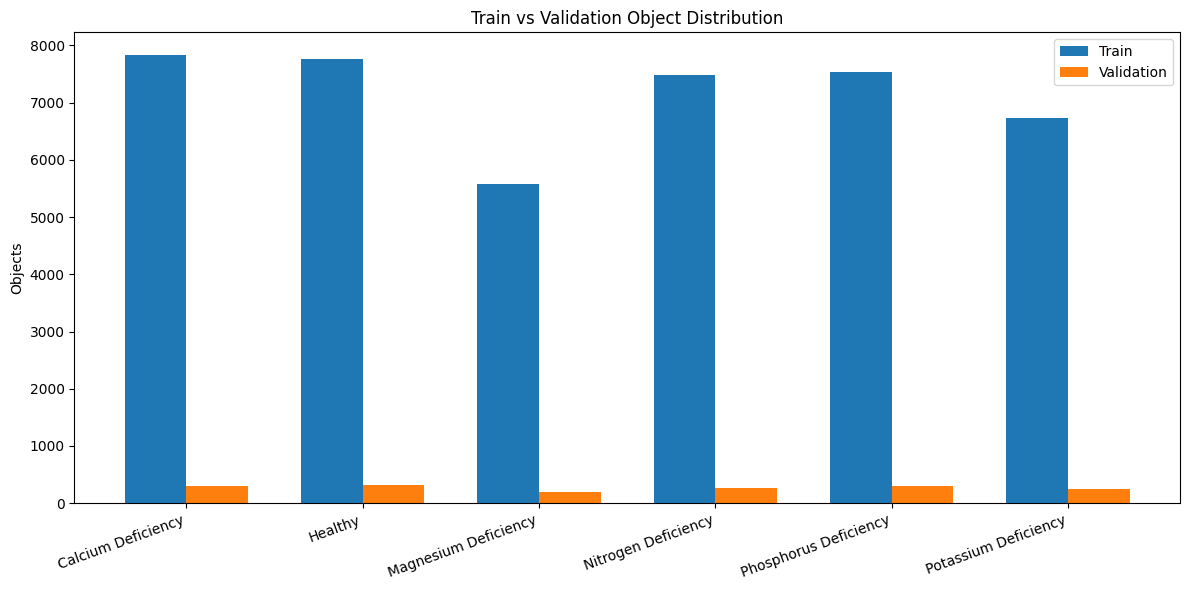

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(CLASS_NAMES))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x-width/2,
    train_df["Objects"],
    width,
    label="Train"
)

plt.bar(
    x+width/2,
    valid_df["Objects"],
    width,
    label="Validation"
)

plt.xticks(
    x,
    CLASS_NAMES,
    rotation=20,
    ha="right"
)

plt.ylabel("Objects")

plt.title("Train vs Validation Object Distribution")

plt.legend()

plt.tight_layout()

plt.show()

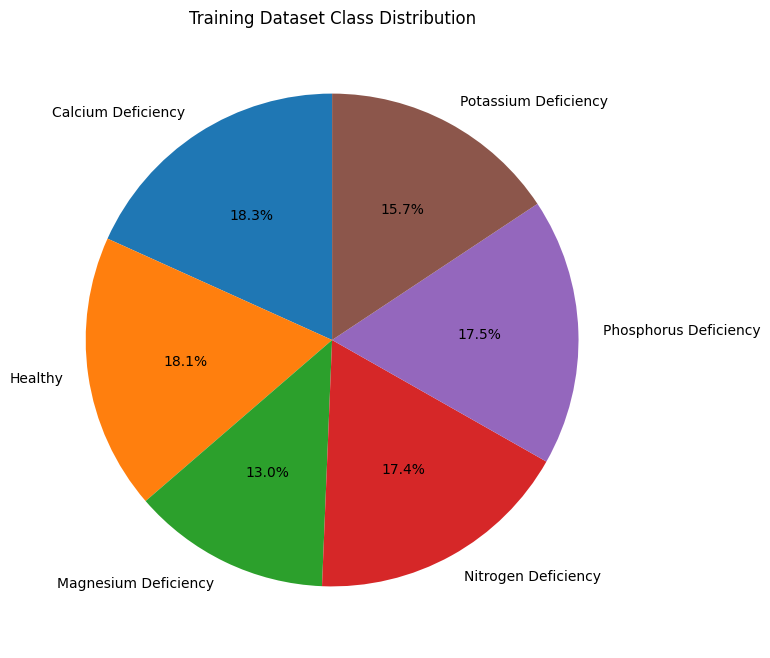

In [17]:
plt.figure(figsize=(8,8))

plt.pie(
    train_df["Objects"],
    labels=train_df["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Training Dataset Class Distribution")

plt.show()

In [18]:
print("="*70)
print("CLASS BALANCE ANALYSIS")
print("="*70)

max_percent = train_df["Objects (%)"].max()
min_percent = train_df["Objects (%)"].min()

imbalance = max_percent - min_percent

print(f"Maximum Class Percentage : {max_percent:.2f}%")
print(f"Minimum Class Percentage : {min_percent:.2f}%")
print(f"Difference               : {imbalance:.2f}%")

print()

if imbalance < 10:
    print("✅ Dataset is WELL BALANCED.")
elif imbalance < 20:
    print("⚠ Moderate class imbalance detected.")
else:
    print("❌ Severe class imbalance detected.")

CLASS BALANCE ANALYSIS
Maximum Class Percentage : 18.25%
Minimum Class Percentage : 13.01%
Difference               : 5.24%

✅ Dataset is WELL BALANCED.


In [19]:
print("="*80)
print("INTERPRETATION")
print("="*80)

largest = train_df.loc[train_df["Objects"].idxmax()]
smallest = train_df.loc[train_df["Objects"].idxmin()]

print(f"Largest Class  : {largest['Class']} ({largest['Objects']} objects)")
print(f"Smallest Class : {smallest['Class']} ({smallest['Objects']} objects)")

print()

print("Observations:")

if imbalance < 10:
    print("✔ Classes are uniformly distributed.")
    print("✔ No significant bias towards a single nutrient deficiency.")
    print("✔ Suitable for YOLO training.")
else:
    print("⚠ Dataset may require balancing.")

INTERPRETATION
Largest Class  : Calcium Deficiency (7837 objects)
Smallest Class : Magnesium Deficiency (5586 objects)

Observations:
✔ Classes are uniformly distributed.
✔ No significant bias towards a single nutrient deficiency.
✔ Suitable for YOLO training.


In [20]:
import cv2
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

def image_statistics(image_folder):

    data=[]

    image_files=[
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]

    for img_name in tqdm(image_files):

        path=os.path.join(image_folder,img_name)

        img=cv2.imread(path)

        if img is None:
            continue

        rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        h,w=gray.shape

        brightness=np.mean(gray)

        contrast=np.std(gray)

        sharpness=cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()

        r_mean=np.mean(rgb[:,:,0])
        g_mean=np.mean(rgb[:,:,1])
        b_mean=np.mean(rgb[:,:,2])

        data.append([
            img_name,
            w,
            h,
            brightness,
            contrast,
            sharpness,
            r_mean,
            g_mean,
            b_mean
        ])

    df=pd.DataFrame(
        data,
        columns=[
            "Image",
            "Width",
            "Height",
            "Brightness",
            "Contrast",
            "Sharpness",
            "Red",
            "Green",
            "Blue"
        ]
    )

    return df

In [21]:
train_img_stats=image_statistics(TRAIN_IMAGES)

valid_img_stats=image_statistics(VALID_IMAGES)

100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:06<00:00, 16.37it/s]


In [22]:
print("="*80)
print("TRAIN IMAGE STATISTICS")
print("="*80)

display(train_img_stats.describe().T)

print()

print("="*80)
print("VALID IMAGE STATISTICS")
print("="*80)

display(valid_img_stats.describe().T)

TRAIN IMAGE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Width,2870.0,640.000000,0.000000,640.000000,640.000000,640.000000,640.000000,640.000000
Height,2870.0,640.000000,0.000000,640.000000,640.000000,640.000000,640.000000,640.000000
Brightness,2870.0,108.112464,11.448508,61.850916,100.734968,108.031815,115.382623,163.505603
Contrast,2870.0,51.494947,5.567789,38.028951,47.087633,51.480903,55.482676,66.034582
Sharpness,2870.0,852.978486,496.049152,180.349577,491.603928,726.733783,1051.648365,3554.735561
Red,2870.0,99.117911,16.328724,44.128105,89.189745,98.534875,109.379510,165.856409
Green,2870.0,119.852981,12.299418,69.890330,112.425524,121.024641,127.192550,165.021096
Blue,2870.0,71.285681,23.124706,20.553809,50.809070,70.558229,89.472933,161.732214



VALID IMAGE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Width,107.0,640.000000,0.000000,640.000000,640.000000,640.000000,640.000000,640.000000
Height,107.0,640.000000,0.000000,640.000000,640.000000,640.000000,640.000000,640.000000
Brightness,107.0,108.596385,11.816621,70.171296,101.916006,109.791323,116.563835,133.576570
Contrast,107.0,52.003193,5.499606,40.027348,47.815558,52.486918,55.924200,64.161147
Sharpness,107.0,790.386316,435.041745,184.503899,460.083409,667.520095,978.568778,2170.396723
Red,107.0,100.005449,16.706645,63.344124,90.378390,98.282019,112.458844,138.971257
Green,107.0,120.121316,13.060759,70.870493,111.870470,121.155334,128.541130,155.068403
Blue,107.0,71.804262,22.625919,21.837412,53.305414,70.411775,91.490201,117.580151


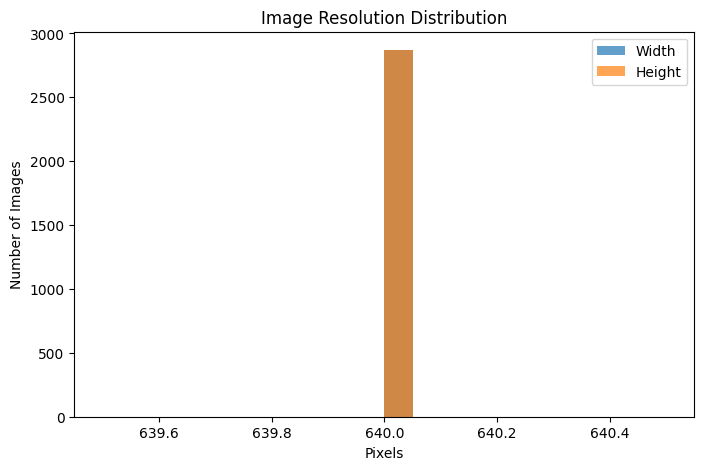

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    train_img_stats["Width"],
    bins=20,
    alpha=0.7,
    label="Width"
)

plt.hist(
    train_img_stats["Height"],
    bins=20,
    alpha=0.7,
    label="Height"
)

plt.title("Image Resolution Distribution")

plt.xlabel("Pixels")

plt.ylabel("Number of Images")

plt.legend()

plt.show()

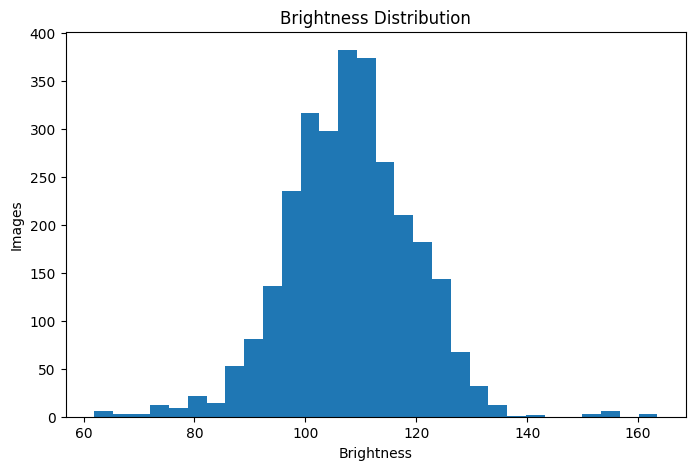

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    train_img_stats["Brightness"],
    bins=30
)

plt.title("Brightness Distribution")

plt.xlabel("Brightness")

plt.ylabel("Images")

plt.show()

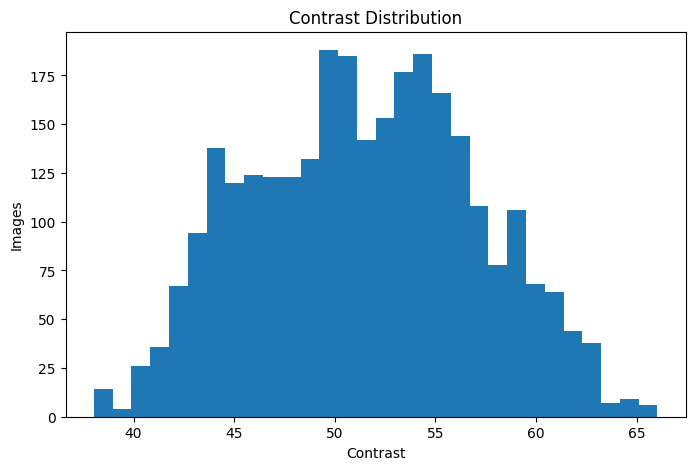

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    train_img_stats["Contrast"],
    bins=30
)

plt.title("Contrast Distribution")

plt.xlabel("Contrast")

plt.ylabel("Images")

plt.show()

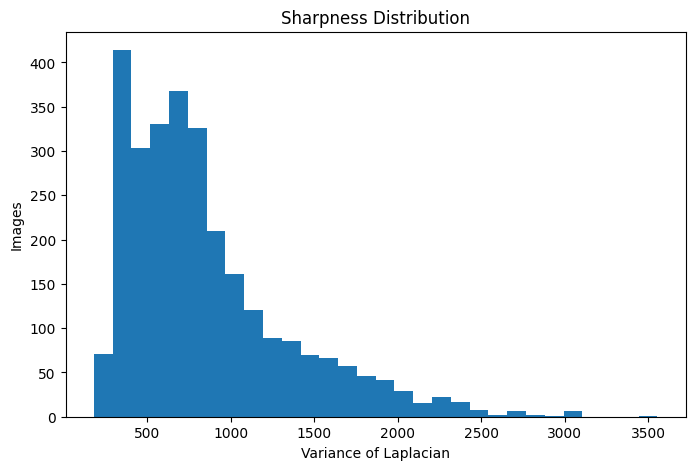

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    train_img_stats["Sharpness"],
    bins=30
)

plt.title("Sharpness Distribution")

plt.xlabel("Variance of Laplacian")

plt.ylabel("Images")

plt.show()

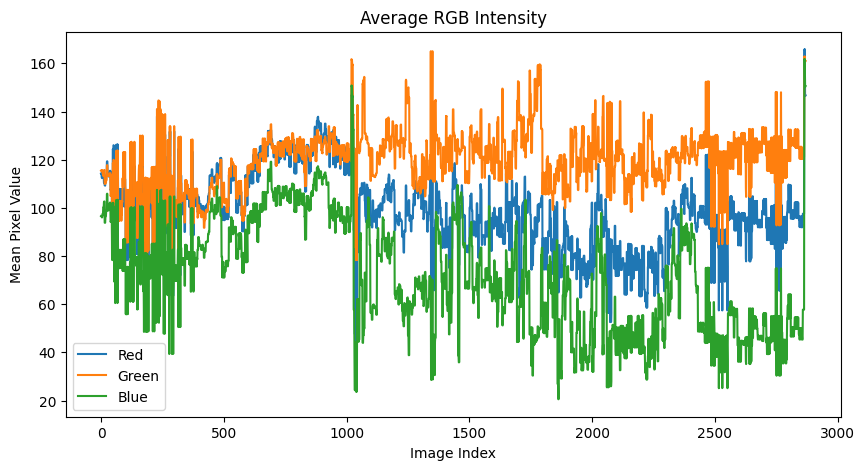

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    train_img_stats["Red"],
    label="Red"
)

plt.plot(
    train_img_stats["Green"],
    label="Green"
)

plt.plot(
    train_img_stats["Blue"],
    label="Blue"
)

plt.title("Average RGB Intensity")

plt.xlabel("Image Index")

plt.ylabel("Mean Pixel Value")

plt.legend()

plt.show()

In [28]:
print("="*80)
print("IMAGE QUALITY REPORT")
print("="*80)

brightness=train_img_stats["Brightness"].mean()

contrast=train_img_stats["Contrast"].mean()

sharpness=train_img_stats["Sharpness"].mean()

print(f"Average Brightness : {brightness:.2f}")
print(f"Average Contrast   : {contrast:.2f}")
print(f"Average Sharpness  : {sharpness:.2f}")

print()

if brightness<70:
    print("⚠ Images are generally dark.")

elif brightness>190:
    print("⚠ Images are generally overexposed.")

else:
    print("✅ Brightness is well balanced.")

if contrast<20:
    print("⚠ Low contrast detected.")

else:
    print("✅ Good contrast.")

if sharpness<100:
    print("⚠ Many blurry images.")

else:
    print("✅ Images are sufficiently sharp.")

IMAGE QUALITY REPORT
Average Brightness : 108.11
Average Contrast   : 51.49
Average Sharpness  : 852.98

✅ Brightness is well balanced.
✅ Good contrast.
✅ Images are sufficiently sharp.


In [29]:
print("="*80)
print("INTERPRETATION")
print("="*80)

print("""
This analysis evaluates the visual quality of the training dataset.

Brightness:
A balanced brightness distribution indicates that the dataset
contains neither predominantly dark nor overexposed images.

Contrast:
Adequate contrast improves feature extraction and helps the
segmentation model distinguish leaf boundaries.

Sharpness:
The variance of the Laplacian estimates image blur.
Higher values indicate sharper images, which generally
improve segmentation accuracy.

RGB Distribution:
The average RGB values help identify strong color bias that
could reduce model generalization.

Overall:
If brightness, contrast, and sharpness are reasonably
distributed without extreme outliers, the dataset is
considered suitable for training deep learning models.
""")

INTERPRETATION

This analysis evaluates the visual quality of the training dataset.

Brightness:
A balanced brightness distribution indicates that the dataset
contains neither predominantly dark nor overexposed images.

Contrast:
Adequate contrast improves feature extraction and helps the
segmentation model distinguish leaf boundaries.

Sharpness:
The variance of the Laplacian estimates image blur.
Higher values indicate sharper images, which generally
improve segmentation accuracy.

RGB Distribution:
The average RGB values help identify strong color bias that
could reduce model generalization.

Overall:
If brightness, contrast, and sharpness are reasonably
distributed without extreme outliers, the dataset is
considered suitable for training deep learning models.



In [30]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def extract_mask_statistics(image_folder, label_folder, class_names):

    records = []

    image_files = [
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for img_name in tqdm(image_files):

        img_path = os.path.join(image_folder, img_name)
        label_path = os.path.join(
            label_folder,
            os.path.splitext(img_name)[0] + ".txt"
        )

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w = img.shape[:2]

        if not os.path.exists(label_path):
            continue

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            values = line.strip().split()

            if len(values) < 7:
                continue

            cls = int(values[0])

            coords = np.array(
                list(map(float, values[1:])),
                dtype=np.float32
            ).reshape(-1,2)

            coords[:,0] *= w
            coords[:,1] *= h

            x = coords[:,0]
            y = coords[:,1]

            xmin = np.min(x)
            xmax = np.max(x)

            ymin = np.min(y)
            ymax = np.max(y)

            bw = xmax - xmin
            bh = ymax - ymin

            bbox_area = bw * bh

            mask_area = cv2.contourArea(coords.astype(np.float32))

            relative_area = (
                mask_area /
                (w*h)
            ) * 100

            polygon_points = len(coords)

            records.append([
                img_name,
                class_names[cls],
                polygon_points,
                bw,
                bh,
                bbox_area,
                mask_area,
                relative_area
            ])

    return pd.DataFrame(
        records,
        columns=[
            "Image",
            "Class",
            "Polygon Points",
            "BBox Width",
            "BBox Height",
            "BBox Area",
            "Mask Area",
            "Relative Area (%)"
        ]
    )

In [31]:
mask_stats = extract_mask_statistics(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    CLASS_NAMES
)

100%|██████████████████████████████████████████████████████████████████████████████| 2870/2870 [00:50<00:00, 56.76it/s]


In [32]:
display(mask_stats.head())

display(mask_stats.describe().T)

,Image,Class,Polygon Points,BBox Width,BBox Height,BBox Area,Mask Area,Relative Area (%)
0,0603174142_jpg.rf.0e25a2e0cff9d6455672f6e919bc...,Calcium Deficiency,166,148.032532,200.294098,29650.042969,15679.005145,3.827882
1,0603174142_jpg.rf.0e25a2e0cff9d6455672f6e919bc...,Calcium Deficiency,120,86.634171,135.784302,11763.560547,7581.374629,1.850922
2,0603174142_jpg.rf.0e25a2e0cff9d6455672f6e919bc...,Calcium Deficiency,149,126.178864,194.509811,24543.027344,12418.964936,3.031974
3,0603174142_jpg.rf.0e25a2e0cff9d6455672f6e919bc...,Calcium Deficiency,108,83.642273,135.000000,11291.707031,7188.100676,1.754907
4,0603174142_jpg.rf.0e25a2e0cff9d6455672f6e919bc...,Calcium Deficiency,181,137.495941,217.352936,29885.146484,18131.904475,4.426734


,count,mean,std,min,25%,50%,75%,max
Polygon Points,42938.0,118.142787,56.369114,4.000000,79.000000,109.000000,146.000000,428.000000
BBox Width,42938.0,152.514847,65.235916,0.627441,103.934967,142.509796,191.208969,521.744995
BBox Height,42938.0,155.407104,64.819595,1.560974,107.843040,145.882355,193.262005,521.744995
BBox Area,42938.0,26062.841797,19415.998047,2.287572,11774.357910,20897.642578,35307.253906,210211.000000
Mask Area,42938.0,15420.492408,11527.479428,1.143786,7117.250229,12455.717990,20833.144844,133390.622962
Relative Area (%),42938.0,3.764769,2.814326,0.000279,1.737610,3.040947,5.086217,32.566070


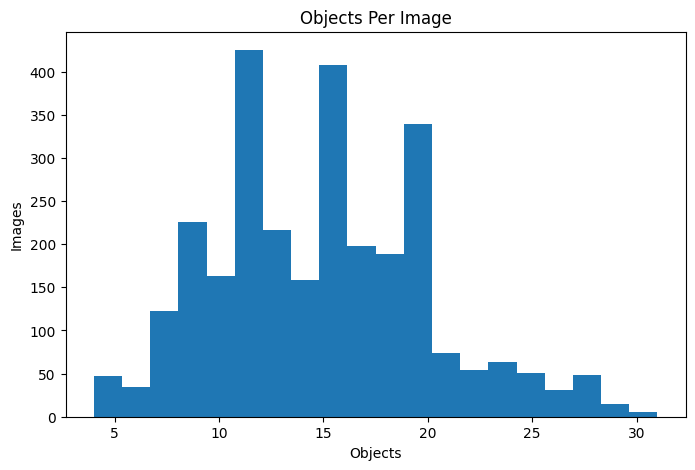


count    2870.000000
mean       14.960976
std         5.068772
min         4.000000
25%        11.000000
50%        15.000000
75%        18.000000
max        31.000000
dtype: float64


In [33]:
objects_per_image = (
    mask_stats
    .groupby("Image")
    .size()
)

plt.figure(figsize=(8,5))

plt.hist(
    objects_per_image,
    bins=20
)

plt.title("Objects Per Image")

plt.xlabel("Objects")

plt.ylabel("Images")

plt.show()

print()

print(objects_per_image.describe())

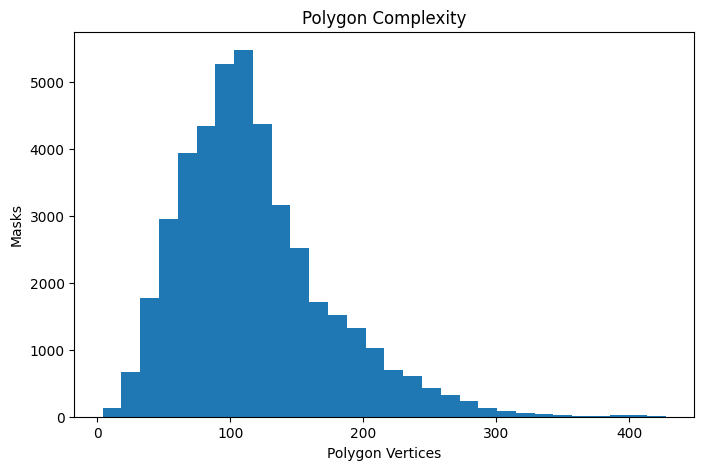

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    mask_stats["Polygon Points"],
    bins=30
)

plt.title("Polygon Complexity")

plt.xlabel("Polygon Vertices")

plt.ylabel("Masks")

plt.show()

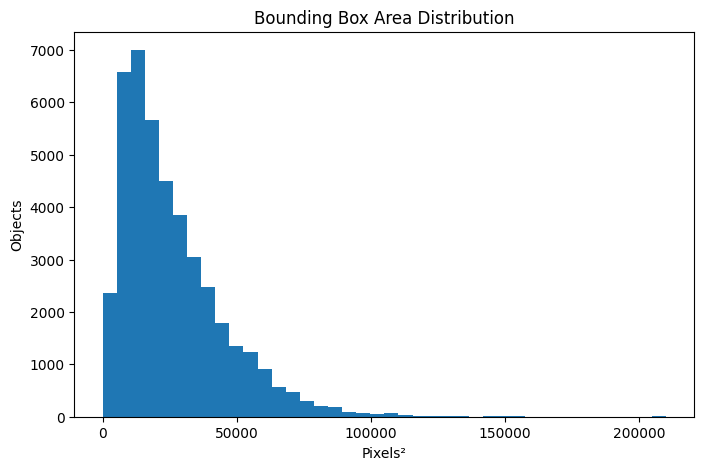

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    mask_stats["BBox Area"],
    bins=40
)

plt.title("Bounding Box Area Distribution")

plt.xlabel("Pixels²")

plt.ylabel("Objects")

plt.show()

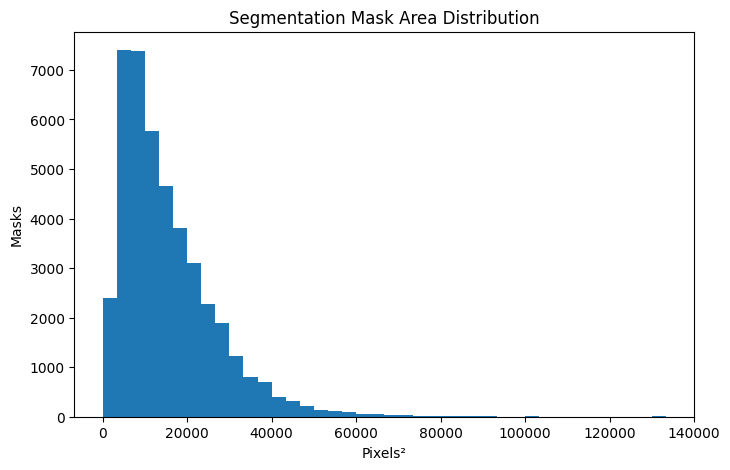

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    mask_stats["Mask Area"],
    bins=40
)

plt.title("Segmentation Mask Area Distribution")

plt.xlabel("Pixels²")

plt.ylabel("Masks")

plt.show()

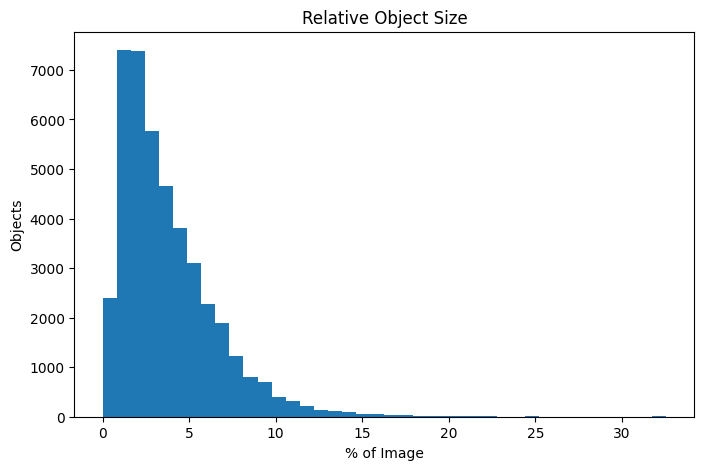

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    mask_stats["Relative Area (%)"],
    bins=40
)

plt.title("Relative Object Size")

plt.xlabel("% of Image")

plt.ylabel("Objects")

plt.show()

,Category,Count
0,Small,31899
1,Medium,10979
2,Large,60


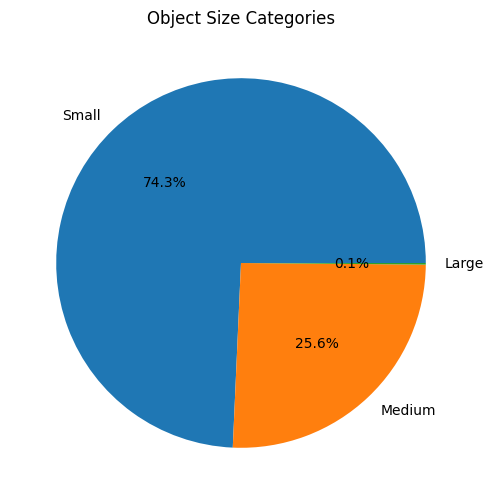

In [38]:
small = (
    mask_stats["Relative Area (%)"] < 5
).sum()

medium = (
    (mask_stats["Relative Area (%)"] >= 5) &
    (mask_stats["Relative Area (%)"] < 20)
).sum()

large = (
    mask_stats["Relative Area (%)"] >= 20
).sum()

distribution = pd.DataFrame({
    "Category":[
        "Small",
        "Medium",
        "Large"
    ],
    "Count":[
        small,
        medium,
        large
    ]
})

display(distribution)

plt.figure(figsize=(6,6))

plt.pie(
    distribution["Count"],
    labels=distribution["Category"],
    autopct="%1.1f%%"
)

plt.title("Object Size Categories")

plt.show()

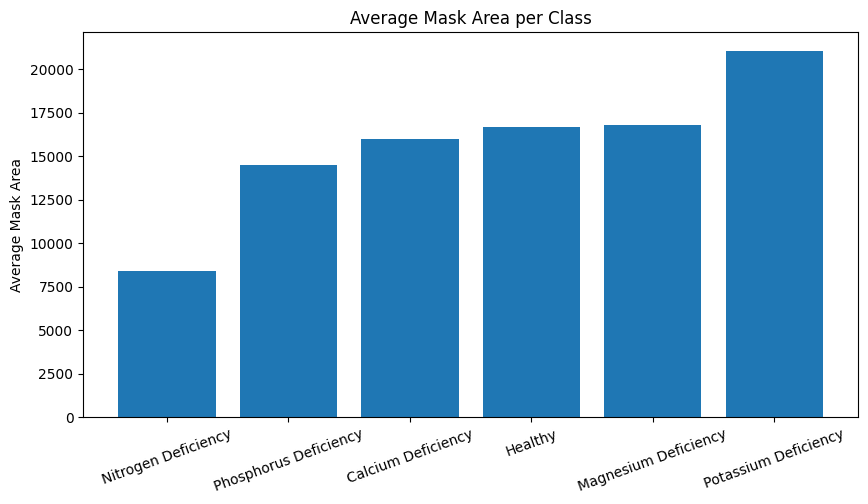

In [39]:
avg_area = (
    mask_stats
    .groupby("Class")["Mask Area"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

plt.bar(
    avg_area.index,
    avg_area.values
)

plt.xticks(rotation=20)

plt.ylabel("Average Mask Area")

plt.title("Average Mask Area per Class")

plt.show()

In [40]:
print("="*80)
print("MASK STATISTICS REPORT")
print("="*80)

print(f"Total Masks : {len(mask_stats):,}")

print(f"Average Polygon Points : {mask_stats['Polygon Points'].mean():.2f}")

print(f"Average Mask Area : {mask_stats['Mask Area'].mean():.2f}")

print(f"Average Relative Area : {mask_stats['Relative Area (%)'].mean():.2f}%")

print()

print("Object Size Distribution")

display(distribution)

print()

if distribution.loc[distribution.Category=="Small","Count"].values[0] > len(mask_stats)*0.6:
    print("⚠ Dataset is dominated by very small objects.")
else:
    print("✅ Object sizes are reasonably distributed.")

if mask_stats["Polygon Points"].mean() < 20:
    print("⚠ Very simple polygons detected.")
else:
    print("✅ Polygon annotations are sufficiently detailed.")

print()

print("Overall Assessment")

print("✔ Segmentation annotations appear suitable for YOLO training.")

MASK STATISTICS REPORT
Total Masks : 42,938
Average Polygon Points : 118.14
Average Mask Area : 15420.49
Average Relative Area : 3.76%

Object Size Distribution


,Category,Count
0,Small,31899
1,Medium,10979
2,Large,60



⚠ Dataset is dominated by very small objects.
✅ Polygon annotations are sufficiently detailed.

Overall Assessment
✔ Segmentation annotations appear suitable for YOLO training.


In [42]:
import os
import cv2
import imagehash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

import torch
import torchvision.models as models
import torchvision.transforms as transforms

In [43]:
train_images = [
    os.path.join(TRAIN_IMAGES, f)
    for f in os.listdir(TRAIN_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

valid_images = [
    os.path.join(VALID_IMAGES, f)
    for f in os.listdir(VALID_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Train Images :", len(train_images))
print("Validation Images :", len(valid_images))

Train Images : 2870
Validation Images : 107


In [44]:
def compute_phash(path):

    img = Image.open(path).convert("RGB")

    return imagehash.phash(img)

In [45]:
train_hashes = {}

for img in tqdm(train_images):

    train_hashes[img] = compute_phash(img)

100%|██████████████████████████████████████████████████████████████████████████████| 2870/2870 [00:49<00:00, 58.32it/s]


In [46]:
valid_hashes = {}

for img in tqdm(valid_images):

    valid_hashes[img] = compute_phash(img)

100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:01<00:00, 92.05it/s]


In [47]:
duplicates = []

for v_path, v_hash in tqdm(valid_hashes.items()):

    for t_path, t_hash in train_hashes.items():

        distance = v_hash - t_hash

        similarity = 1 - distance / 64

        if similarity > 0.95:

            duplicates.append([
                os.path.basename(t_path),
                os.path.basename(v_path),
                similarity
            ])

duplicates = pd.DataFrame(
    duplicates,
    columns=[
        "Train Image",
        "Validation Image",
        "Similarity"
    ]
)

duplicates

100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:02<00:00, 44.39it/s]


,Train Image,Validation Image,Similarity
0,0603181532_jpg.rf.b4b0edbc171acd493fd5a1e11bcf...,0603181354_jpg.rf.a66e0313db0de17692b0faa761b9...,1.00000
1,0603190849_jpg.rf.5c1486177405899d70be64fd94a1...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
2,0603190849_jpg.rf.6fce2b7022a5f66cad5a0aa4be86...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
3,0603190849_jpg.rf.f2964963010da22ae1d398fdccf2...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
4,0603192708_jpg.rf.3d6f8f3fecc62870b2a63cd516fc...,0603192708_jpg.rf.099c15d9abffade8cf46a67b9fe8...,0.96875
5,0603192708_jpg.rf.e77deac88b158649fe5844486da9...,0603192708_jpg.rf.099c15d9abffade8cf46a67b9fe8...,0.96875
6,0603192939_jpg.rf.ea94b465aae4f590ad2c770b71ac...,0603192939_jpg.rf.704bb0f88772fa68d747e9cbd8df...,1.00000
7,0603193242_jpg.rf.686ba7e730e85574340f7561098a...,0603193242_jpg.rf.ae27a5c005cad673c8832a4a8869...,1.00000
8,0603193242_jpg.rf.90fea4cce479c9c965e880ff0eca...,0603193242_jpg.rf.ae27a5c005cad673c8832a4a8869...,1.00000
9,0603193501_jpg.rf.15ee58896843c306ce50c5e30e50...,0603193501_jpg.rf.1a695c465022c148d0554b1b9b1f...,1.00000


In [48]:
print("="*80)

print("PHASH LEAKAGE REPORT")

print("="*80)

print("Potential Duplicates :", len(duplicates))

if len(duplicates)==0:

    print("✅ No duplicate images found.")

else:

    display(duplicates.sort_values(
        "Similarity",
        ascending=False
    ))

PHASH LEAKAGE REPORT
Potential Duplicates : 40


,Train Image,Validation Image,Similarity
0,0603181532_jpg.rf.b4b0edbc171acd493fd5a1e11bcf...,0603181354_jpg.rf.a66e0313db0de17692b0faa761b9...,1.00000
1,0603190849_jpg.rf.5c1486177405899d70be64fd94a1...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
2,0603190849_jpg.rf.6fce2b7022a5f66cad5a0aa4be86...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
3,0603190849_jpg.rf.f2964963010da22ae1d398fdccf2...,0603190849_jpg.rf.3255b352cda2e903f2a03eec3a42...,1.00000
7,0603193242_jpg.rf.686ba7e730e85574340f7561098a...,0603193242_jpg.rf.ae27a5c005cad673c8832a4a8869...,1.00000
6,0603192939_jpg.rf.ea94b465aae4f590ad2c770b71ac...,0603192939_jpg.rf.704bb0f88772fa68d747e9cbd8df...,1.00000
9,0603193501_jpg.rf.15ee58896843c306ce50c5e30e50...,0603193501_jpg.rf.1a695c465022c148d0554b1b9b1f...,1.00000
8,0603193242_jpg.rf.90fea4cce479c9c965e880ff0eca...,0603193242_jpg.rf.ae27a5c005cad673c8832a4a8869...,1.00000
38,IMG20230605082538_jpg.rf.29dd60541eeec92091039...,IMG20230605082538_jpg.rf.e6bb8ec330ebb7d122682...,1.00000
27,IMG20230605082502_jpg.rf.969365c01e0db75638b56...,IMG20230605082502_jpg.rf.31c80e63429a9e54480f8...,1.00000


In [49]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.fc = torch.nn.Identity()

model.eval()

model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:28<00:00, 3.65MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [50]:
transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [51]:
@torch.no_grad()

def embedding(path):

    img=cv2.imread(path)

    img=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img=transform(img)

    img=img.unsqueeze(0).to(device)

    vec=model(img)

    return vec.cpu().numpy()[0]

In [52]:
train_embeddings={}

for img in tqdm(train_images):

    train_embeddings[img]=embedding(img)

100%|██████████████████████████████████████████████████████████████████████████████| 2870/2870 [03:43<00:00, 12.82it/s]


In [53]:
valid_embeddings={}

for img in tqdm(valid_images):

    valid_embeddings[img]=embedding(img)

100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [00:07<00:00, 14.17it/s]


In [54]:
similarity_results=[]

for v_img,v_vec in tqdm(valid_embeddings.items()):

    best_score=0
    best_train=None

    for t_img,t_vec in train_embeddings.items():

        score=cosine_similarity(
            [v_vec],
            [t_vec]
        )[0][0]

        if score>best_score:

            best_score=score
            best_train=t_img

    similarity_results.append([

        os.path.basename(best_train),

        os.path.basename(v_img),

        best_score

    ])

similarity_results=pd.DataFrame(

    similarity_results,

    columns=[

        "Nearest Train Image",

        "Validation Image",

        "Cosine Similarity"

    ]

)

100%|████████████████████████████████████████████████████████████████████████████████| 107/107 [06:16<00:00,  3.52s/it]


In [55]:
similarity_results.sort_values(

    "Cosine Similarity",

    ascending=False,

    inplace=True

)

display(similarity_results.head(20))

,Nearest Train Image,Validation Image,Cosine Similarity
99,IMG20230605082507_jpg.rf.117100bd41a396bc2ef06...,IMG20230605082507_jpg.rf.9e9be21d4b2e4284db709...,1.000000
66,IMG20230531133714_01_jpg.rf.0349e237ae95f75beb...,IMG20230531133714_01_jpg.rf.ad90ad22d42b2e122f...,1.000000
12,0603193242_jpg.rf.686ba7e730e85574340f7561098a...,0603193242_jpg.rf.ae27a5c005cad673c8832a4a8869...,1.000000
85,IMG20230602082147_jpg.rf.262984cadf2cee64598bb...,IMG20230602082147_jpg.rf.21bd29f4333d2292c97dd...,1.000000
98,IMG20230605082502_jpg.rf.969365c01e0db75638b56...,IMG20230605082502_jpg.rf.31c80e63429a9e54480f8...,1.000000
100,IMG20230605082507_jpg.rf.203ed3cbd1314e3943792...,IMG20230605082507_jpg.rf.e9a6e755c0af1285b0663...,1.000000
101,IMG20230605082511_jpg.rf.3d423d63cdeadb97b3474...,IMG20230605082511_jpg.rf.cb3afe585b477a3554377...,1.000000
19,0605135356_jpg.rf.f565cd3479ef4215f9a723290e7b...,0605135356_jpg.rf.67f824c515f3b2483cf2d33a6200...,1.000000
104,IMG20230605082538_jpg.rf.3c4bb315dd8abdb8f0a48...,IMG20230605082538_jpg.rf.49aed11b819901d95ccac...,1.000000
103,IMG20230605082534_jpg.rf.0faa77834ef45a49538d8...,IMG20230605082534_jpg.rf.e7c8e603dafad103197a4...,1.000000


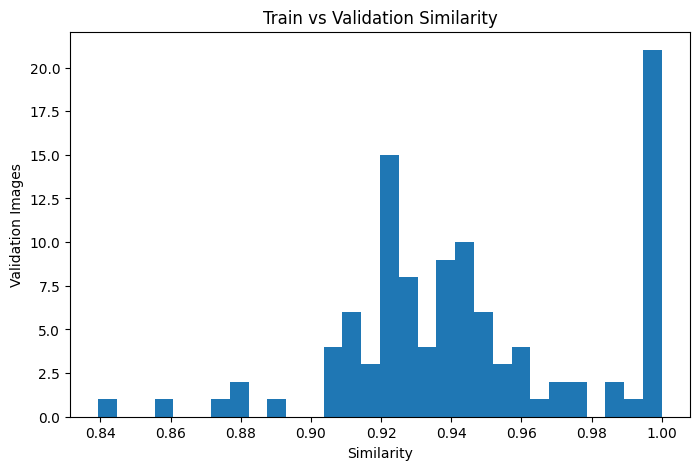

In [56]:
plt.figure(figsize=(8,5))

plt.hist(

    similarity_results["Cosine Similarity"],

    bins=30

)

plt.xlabel("Similarity")

plt.ylabel("Validation Images")

plt.title("Train vs Validation Similarity")

plt.show()

In [57]:
print("="*80)
print("LEAKAGE ANALYSIS")
print("="*80)

max_similarity = similarity_results["Cosine Similarity"].max()
mean_similarity = similarity_results["Cosine Similarity"].mean()

print(f"Highest Similarity : {max_similarity:.4f}")
print(f"Average Similarity : {mean_similarity:.4f}")

high = similarity_results[
    similarity_results["Cosine Similarity"] > 0.98
]

moderate = similarity_results[
    (similarity_results["Cosine Similarity"] > 0.95) &
    (similarity_results["Cosine Similarity"] <= 0.98)
]

print(f"\nImages > 0.98 similarity : {len(high)}")
print(f"Images between 0.95–0.98 : {len(moderate)}")

if len(high) == 0:
    print("\n✅ No strong evidence of train-validation leakage.")
else:
    print("\n⚠ Review the highly similar image pairs shown above.")

LEAKAGE ANALYSIS
Highest Similarity : 1.0000
Average Similarity : 0.9455

Images > 0.98 similarity : 24
Images between 0.95–0.98 : 14

⚠ Review the highly similar image pairs shown above.
